# Fase D — Visualizaciones
**Proyecto 1 — Bodega de delitos Colombia 2025 (DIJIN)** · Grupo 7

8 visualizaciones construidas a partir de las consultas de la Fase C. Cubren los 4 tipos
requeridos: serie de tiempo, comparación categórica, relación bivariada y distribución
univariada (con más de una visualización en varias categorías).


In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv(Path("..", ".env"))
RAIZ_PROYECTO = Path.cwd().parent if Path.cwd().name == "entrega" else Path.cwd()
load_dotenv(RAIZ_PROYECTO / ".env")
DATABASE_URL = os.getenv("DATABASE_URL") or f"sqlite:///{(RAIZ_PROYECTO / 'datos' / 'bodega_delitos.db').as_posix()}"
engine = create_engine(DATABASE_URL)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## Visualización 1 — Evolución mensual de casos (serie de tiempo)

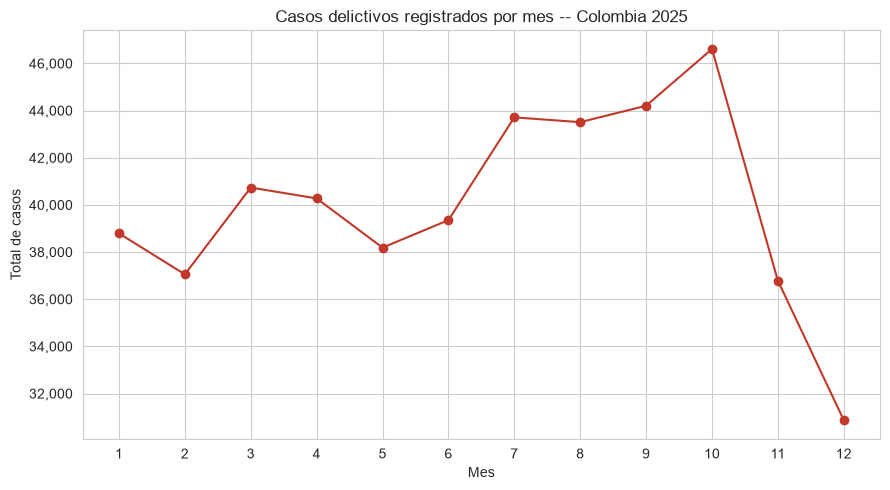

In [4]:
q = """
SELECT t.mes, t.nombre_mes, SUM(h.cantidad) AS total_casos
FROM hecho_delito h JOIN dim_tiempo t ON h.fecha_id = t.fecha_id
GROUP BY t.mes, t.nombre_mes ORDER BY t.mes
"""
d1 = pd.read_sql(q, engine)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(d1["mes"], d1["total_casos"], marker="o", color="#c0392b")
ax.set_title("Casos delictivos registrados por mes -- Colombia 2025")
ax.set_xlabel("Mes")
ax.set_ylabel("Total de casos")
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()


**Insight:** el volumen mensual oscila entre ~30.900 y ~46.600 casos, con un repunte
sostenido de julio a octubre y una caída marcada en noviembre-diciembre. Esa caída de fin de
año probablemente refleja rezago en el reporte de los últimos meses más que una baja real en
la actividad delictiva.

## Visualización 2 — Total de casos por tipo de delito (comparación categórica)

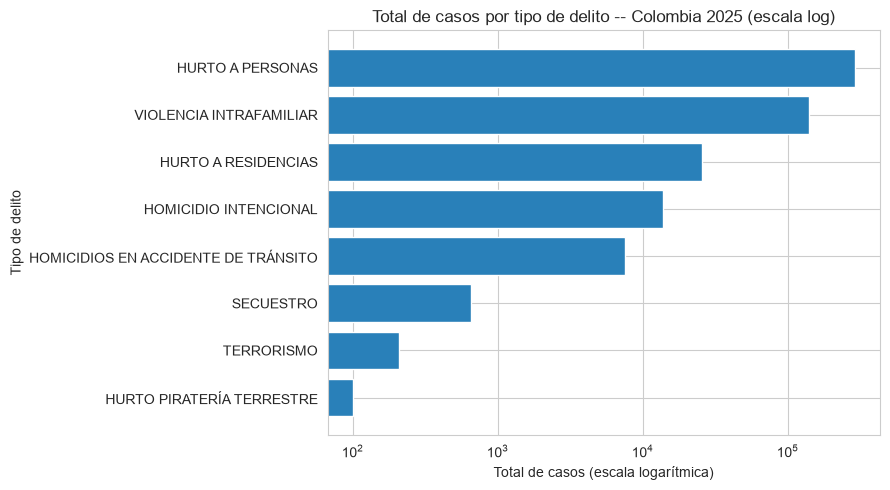

In [5]:
q = """
SELECT d.tipo_delito, SUM(h.cantidad) AS total_casos
FROM hecho_delito h JOIN dim_tipo_delito d ON h.delito_id = d.delito_id
GROUP BY d.tipo_delito ORDER BY total_casos ASC
"""
d2 = pd.read_sql(q, engine)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(d2["tipo_delito"], d2["total_casos"], color="#2980b9")
ax.set_xscale("log")
ax.set_title("Total de casos por tipo de delito -- Colombia 2025 (escala log)")
ax.set_xlabel("Total de casos (escala logarítmica)")
ax.set_ylabel("Tipo de delito")
plt.tight_layout()
plt.show()


**Insight:** hurto a personas (290.891) y violencia intrafamiliar (141.366) concentran la
gran mayoría de los casos, casi dos órdenes de magnitud por encima de secuestro, terrorismo o
piratería terrestre. Se usó escala logarítmica porque, en escala lineal, los delitos de menor
frecuencia serían invisibles junto a hurto a personas.

## Visualización 3 — Hurto a personas por departamento y trimestre (relación bivariada)

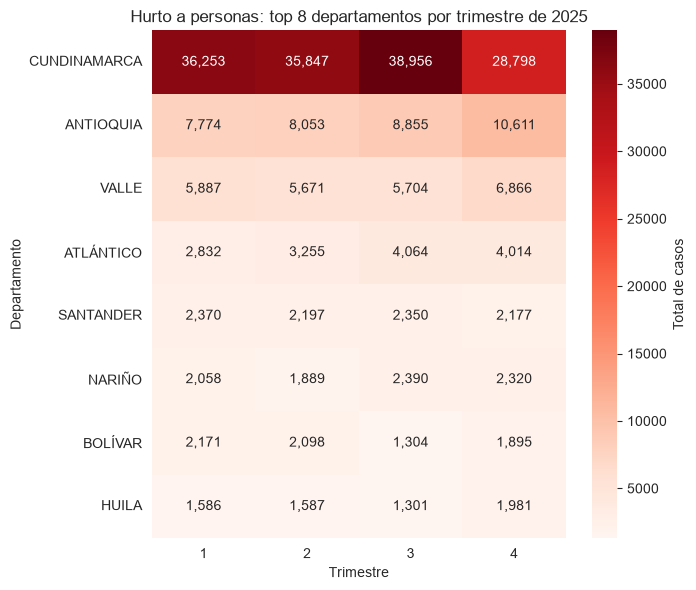

In [6]:
q = """
SELECT g.departamento, t.trimestre, SUM(h.cantidad) AS total_casos
FROM hecho_delito h
JOIN dim_geografia g ON h.geo_id = g.geo_id
JOIN dim_tipo_delito d ON h.delito_id = d.delito_id
JOIN dim_tiempo t ON h.fecha_id = t.fecha_id
WHERE d.tipo_delito = \'HURTO A PERSONAS\'
GROUP BY g.departamento, t.trimestre
"""
d3 = pd.read_sql(q, engine)
top8 = d3.groupby("departamento")["total_casos"].sum().nlargest(8).index
pivote = d3[d3["departamento"].isin(top8)].pivot(index="departamento", columns="trimestre", values="total_casos")
pivote = pivote.loc[pivote.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pivote, annot=True, fmt=",.0f", cmap="Reds", ax=ax, cbar_kws={"label": "Total de casos"})
ax.set_title("Hurto a personas: top 8 departamentos por trimestre de 2025")
ax.set_xlabel("Trimestre")
ax.set_ylabel("Departamento")
plt.tight_layout()
plt.show()


**Insight:** Cundinamarca concentra muchos más casos que cualquier otro departamento en
todos los trimestres (relación clara entre las dos dimensiones), con un pico en el tercer
trimestre. Antioquia y Valle mantienen niveles bastante más bajos y estables a lo largo del
año, sin un patrón estacional tan marcado como el de Cundinamarca.

## Visualización 4 — Distribución de casos por día de la semana (distribución univariada)

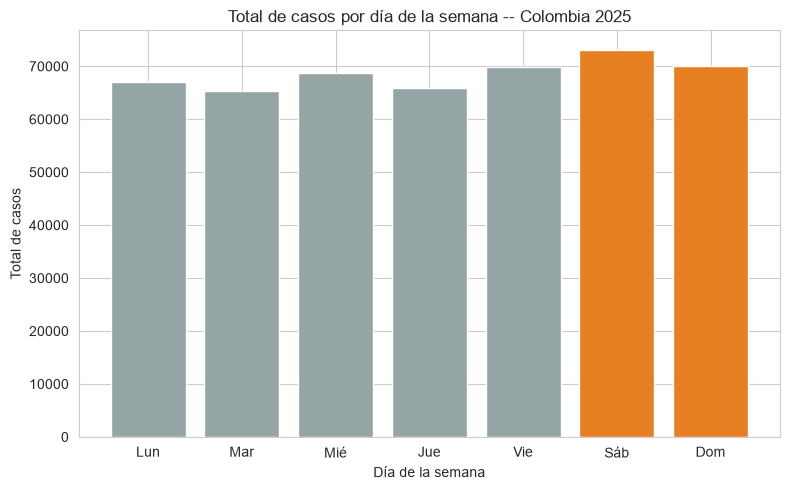

In [7]:
q = """
SELECT t.dia_semana, SUM(h.cantidad) AS total_casos
FROM hecho_delito h JOIN dim_tiempo t ON h.fecha_id = t.fecha_id
GROUP BY t.dia_semana
"""
d4 = pd.read_sql(q, engine)
orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
etiquetas = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
d4["dia_semana"] = pd.Categorical(d4["dia_semana"], categories=orden, ordered=True)
d4 = d4.sort_values("dia_semana")
colores = ["#95a5a6"] * 5 + ["#e67e22"] * 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(etiquetas, d4["total_casos"], color=colores)
ax.set_title("Total de casos por día de la semana -- Colombia 2025")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Total de casos")
plt.tight_layout()
plt.show()


**Insight:** sábado y domingo (en naranja) son individualmente los días con más casos,
por encima de cualquier día entre semana. En promedio por día, el fin de semana acumula
~71.578 casos/día frente a ~67.387 en días hábiles, consistente con mayor actividad social y
de ocio nocturno los fines de semana.

## Visualización 5 — Top 3 municipios por tipo de delito (subconjunto, comparación categórica)

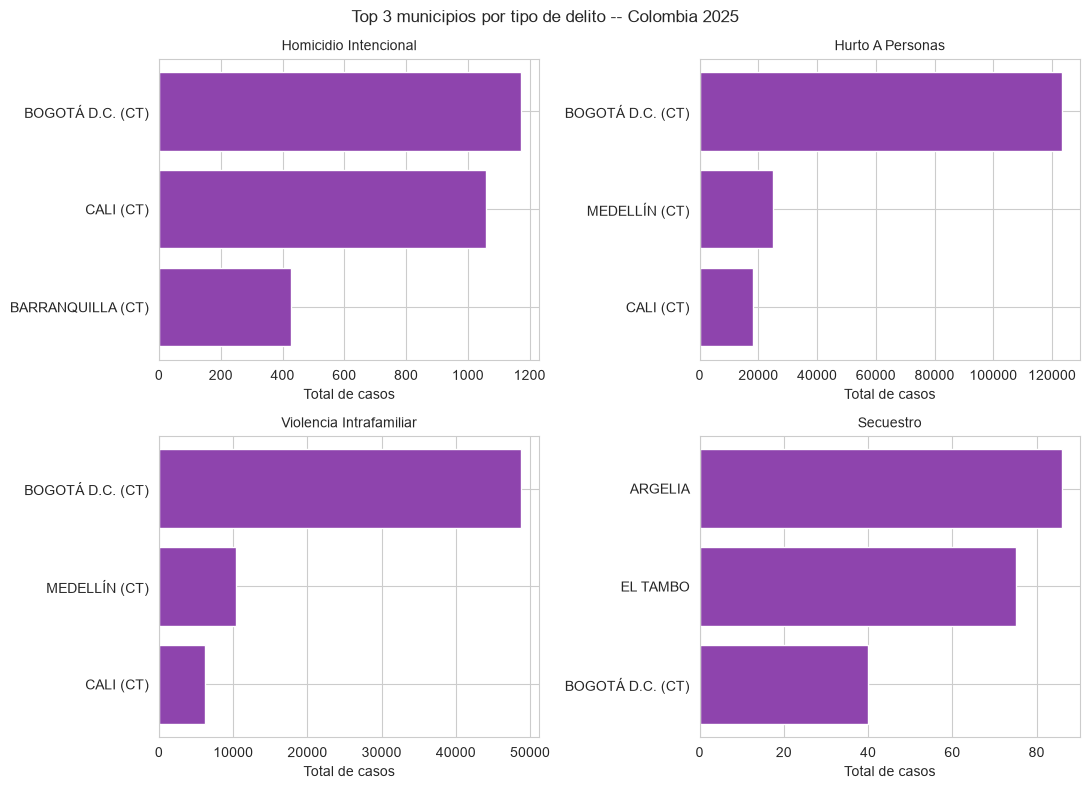

In [8]:
delitos_foco = ["HOMICIDIO INTENCIONAL", "HURTO A PERSONAS", "VIOLENCIA INTRAFAMILIAR", "SECUESTRO"]
q = """
WITH casos_municipio AS (
    SELECT d.tipo_delito, g.municipio, SUM(h.cantidad) AS total_casos
    FROM hecho_delito h
    JOIN dim_tipo_delito d ON h.delito_id = d.delito_id
    JOIN dim_geografia g ON h.geo_id = g.geo_id
    GROUP BY d.tipo_delito, g.municipio
)
SELECT tipo_delito, municipio, total_casos,
       RANK() OVER (PARTITION BY tipo_delito ORDER BY total_casos DESC) AS ranking
FROM casos_municipio
"""
d5 = pd.read_sql(q, engine)
d5 = d5[(d5["ranking"] <= 3) & (d5["tipo_delito"].isin(delitos_foco))]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, delito in zip(axes.flat, delitos_foco):
    sub = d5[d5["tipo_delito"] == delito].sort_values("total_casos")
    ax.barh(sub["municipio"], sub["total_casos"], color="#8e44ad")
    ax.set_title(delito.title(), fontsize=10)
    ax.set_xlabel("Total de casos")
fig.suptitle("Top 3 municipios por tipo de delito -- Colombia 2025")
plt.tight_layout()
plt.show()


**Insight:** Bogotá D.C. lidera en los cuatro delitos mostrados, lo cual es esperable por
su tamaño poblacional. Fuera de Bogotá, el segundo y tercer lugar cambian por completo según el
delito (p. ej. Medellín pesa fuerte en hurto a personas pero no aparece en el top 3 de
secuestro), lo que confirma que la geografía del delito no es uniforme.

## Visualización 6 — Armas o medios empleados en homicidio intencional (comparación categórica)

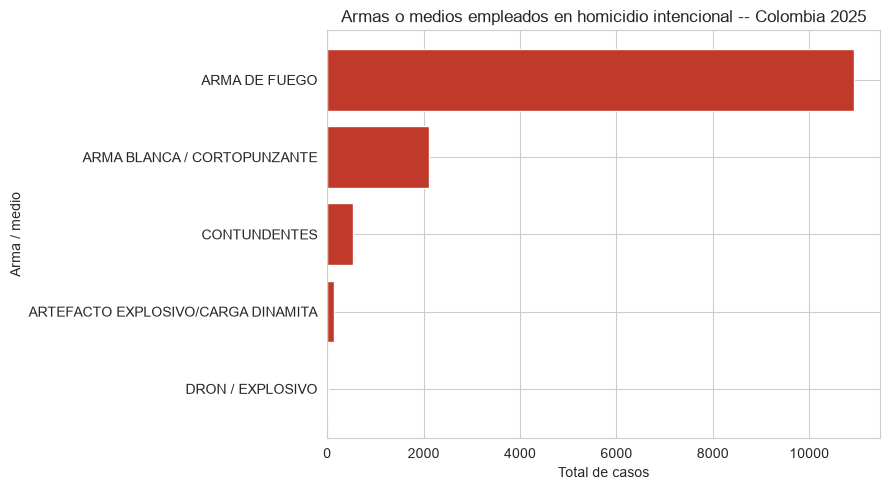

In [9]:
q = """
SELECT a.arma_medio, SUM(h.cantidad) AS total_casos
FROM hecho_delito h
JOIN dim_arma_medio a ON h.arma_id = a.arma_id
JOIN dim_tipo_delito d ON h.delito_id = d.delito_id
WHERE d.tipo_delito = \'HOMICIDIO INTENCIONAL\'
GROUP BY a.arma_medio
HAVING total_casos > 0
ORDER BY total_casos ASC
"""
d6 = pd.read_sql(q, engine)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(d6["arma_medio"], d6["total_casos"], color="#c0392b")
ax.set_title("Armas o medios empleados en homicidio intencional -- Colombia 2025")
ax.set_xlabel("Total de casos")
ax.set_ylabel("Arma / medio")
plt.tight_layout()
plt.show()


**Insight:** el arma de fuego es, con amplio margen, el medio más usado en homicidio
intencional, seguida del arma blanca/cortopunzante. Juntas explican la gran mayoría de los
casos, mientras que el resto de categorías (contundentes, sin arma, etc.) son residuales.

## Visualización 7 — Perfil de víctima por género en hurto a personas vs. violencia intrafamiliar (relación bivariada)

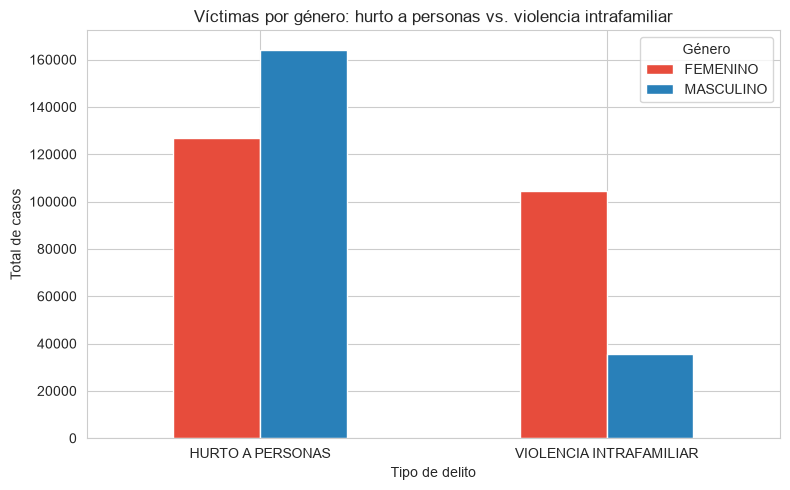

In [10]:
q = """
SELECT d.tipo_delito, v.genero, SUM(h.cantidad) AS total_casos
FROM hecho_delito h
JOIN dim_victima v ON h.victima_id = v.victima_id
JOIN dim_tipo_delito d ON h.delito_id = d.delito_id
WHERE v.genero != \'NO REPORTADO\'
  AND d.tipo_delito IN (\'HURTO A PERSONAS\', \'VIOLENCIA INTRAFAMILIAR\')
GROUP BY d.tipo_delito, v.genero
"""
d7 = pd.read_sql(q, engine)
pivote7 = d7.pivot(index="tipo_delito", columns="genero", values="total_casos")

fig, ax = plt.subplots(figsize=(8, 5))
pivote7.plot(kind="bar", ax=ax, color=["#e74c3c", "#2980b9"])
ax.set_title("Víctimas por género: hurto a personas vs. violencia intrafamiliar")
ax.set_xlabel("Tipo de delito")
ax.set_ylabel("Total de casos")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Género")
plt.tight_layout()
plt.show()


**Insight:** en hurto a personas la proporción por género es relativamente pareja
(masculino ligeramente mayor), mientras que en violencia intrafamiliar hay una brecha marcada:
las víctimas femeninas casi triplican a las masculinas (97.476 vs 30.973). El patrón confirma
que el perfil de víctima depende fuertemente del tipo de delito.

## Visualización 8 — Distribución de víctimas por grupo de edad (distribución univariada)

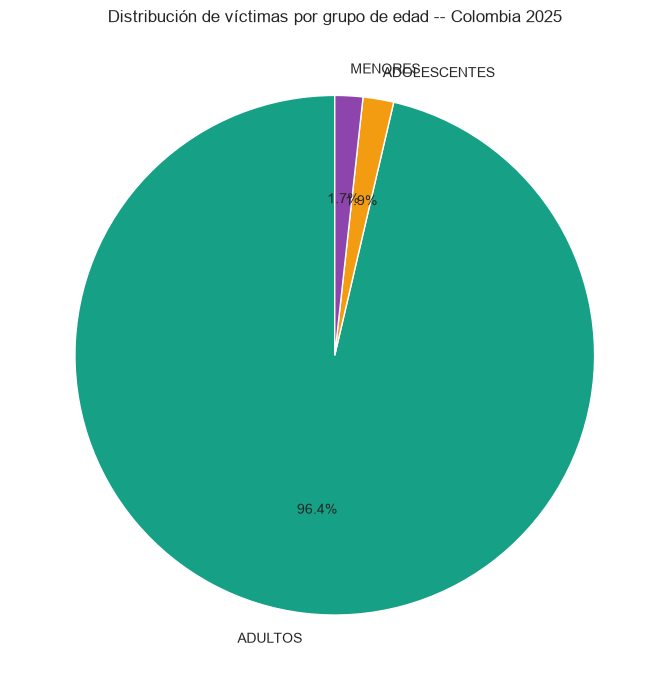

In [11]:
q = """
SELECT v.grupo_edad, SUM(h.cantidad) AS total_casos
FROM hecho_delito h JOIN dim_victima v ON h.victima_id = v.victima_id
WHERE v.grupo_edad != \'NO REPORTADO\'
GROUP BY v.grupo_edad
ORDER BY total_casos DESC
"""
d8 = pd.read_sql(q, engine)

fig, ax = plt.subplots(figsize=(7, 7))
colores8 = ["#16a085", "#f39c12", "#8e44ad"]
ax.pie(
    d8["total_casos"],
    labels=d8["grupo_edad"],
    autopct="%1.1f%%",
    colors=colores8,
    startangle=90,
)
ax.set_title("Distribución de víctimas por grupo de edad -- Colombia 2025")
plt.tight_layout()
plt.show()


**Insight:** los adultos representan la gran mayoría de las víctimas registradas, seguidos
de lejos por adolescentes y menores. Esto es consistente con que hurto a personas y violencia
intrafamiliar -los delitos más frecuentes- involucran mayoritariamente a población adulta.